##### 실행 환경 설정

In [ ]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec08"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/lane-seg"
    !mkdir -p {DATASET_PATH}
    !cp -n {WORK_DIR}{DATASET_PATH}.zip {DATASET_PATH}.zip
    !unzip -qn {DATASET_PATH}.zip -d {DATASET_PATH}
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print()

    # data.yaml의 path를 절대 경로(앞에 / 붙임)로 변경
    import yaml
    yaml_path = "/datasets/lane-seg/data.yaml"
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = '/datasets/lane-seg'
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/lane-seg"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 컴퓨터/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

[데이터셋 폴더 목록]
/datasets/lane-seg
data.yaml  images  labels

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 임포트

In [2]:
%%capture
!pip install -U ultralytics
from ultralytics import YOLO
import torch
from IPython.display import Image, display


##### Device 설정

In [3]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cuda


##### 모델 로드

In [4]:
# 사전 학습된 YOLO 세그멘테이션 모델 로드 (없으면 자동 다운로드)
model = YOLO("yolo11n-seg")
# print(model)

# 모델 구조 요약
model.info()
# YOLO26n-seg summary: 309 layers, 3,126,280 parameters, 0 gradients, 10.509952 GFLOPs
#   - layers    : 모델을 구성하는 총 레이어 수
#   - parameters: 학습 가능한 가중치의 총 개수
#   - gradients : 현재 역전파에 사용 중인 그래디언트 수 (추론 모드에서는 0)
#   - GFLOPs    : 이미지 1장 추론 시 필요한 연산량 (100억 부동소수점 연산)
# 반환값: (layers, parameters, gradients, GFLOPs) 튜플


(203, 2876848, 0, 9.900352)

##### 파인튜닝하기

In [ ]:
train_results = model.train(
    data=f"{DATASET_PATH}/data.yaml",       # data.yaml 경로
    epochs=200,                             # 훈련 에포크 수
    imgsz=320,                              # 이미지 폭 크기
    batch=-1,                               # -1: Ultralytics가 GPU VRAM의 60% 기준으로 자동 계산
    lr0=0.001,                              # 초기 학습률 (기본값 0.01의 1/10)
    # device='',                            # GPU가 있으면 사용 없으면 CPU
    workers=2,                              # 데이터 로더 워커 수
    name="06",                              # 결과가 저장될 폴더 이름, run/segment/06 형태로 저장
    exist_ok=True,                          # 결과 저장 폴더를 덮어쓰기 여부, 기본값 False는 끝에 번호를 붙임
)

train: Scanning /datasets/lane-seg/labels/train... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 3.6Kit/s 0.0s
train: Scanning /datasets/lane-seg/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 48.9Mit/s 0.0s
val: Scanning /datasets/lane-seg/labels/val... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 2.7Kit/s 0.0s
      1/200      3.05G      2.088      4.824      3.746      1.927          0        444        320: 100% ━━━━━━━━━━━━ 1/1 4.5s/it 4.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
      2/200      3.05G      1.912      4.556      3.686      1.831          0        390        320: 100% ━━━━━━━━━━━━ 1/1 10.9it/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.0it/s 0.1s
      3

학습 결과 확인

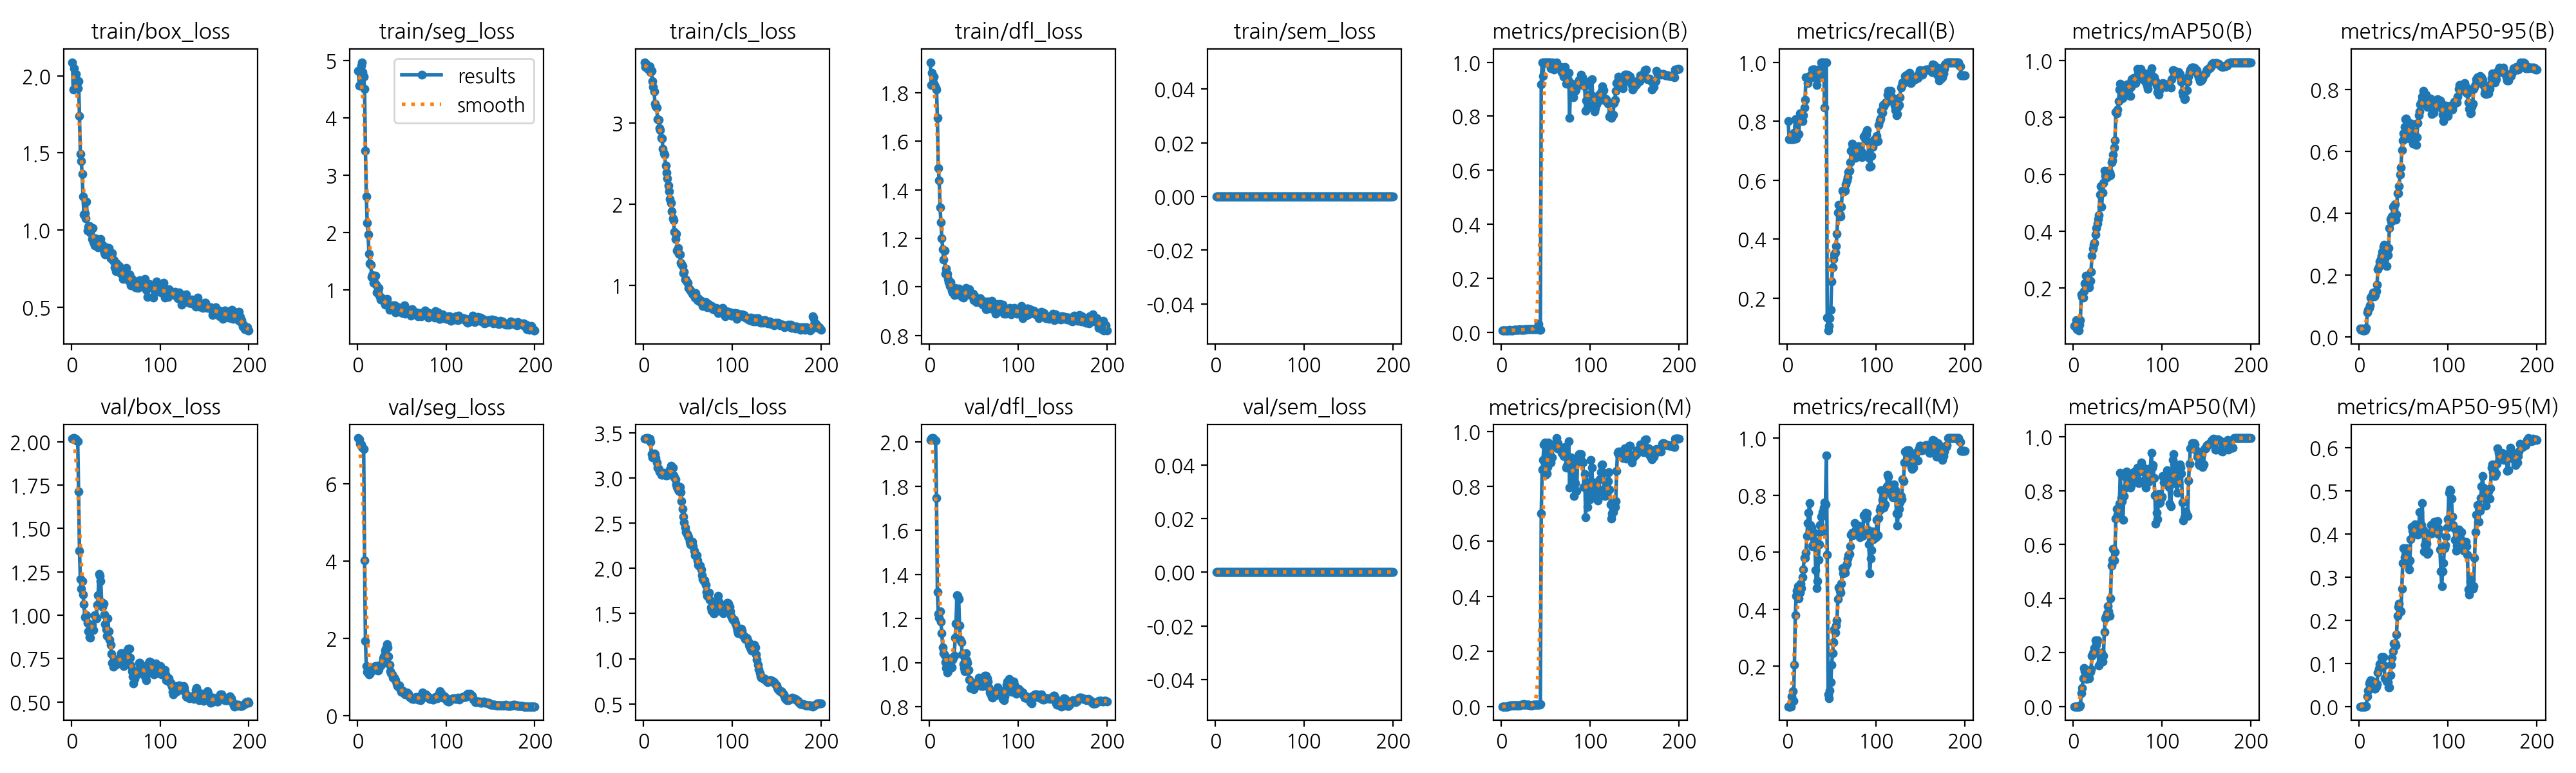

In [6]:
# 훈련/검증 손실 및 mAP 그래프
results_png_path = f"runs/segment/06/results.png"
display(Image(results_png_path))

혼동 행렬  
- 정답, 오답, 못찾음(background)의 비율

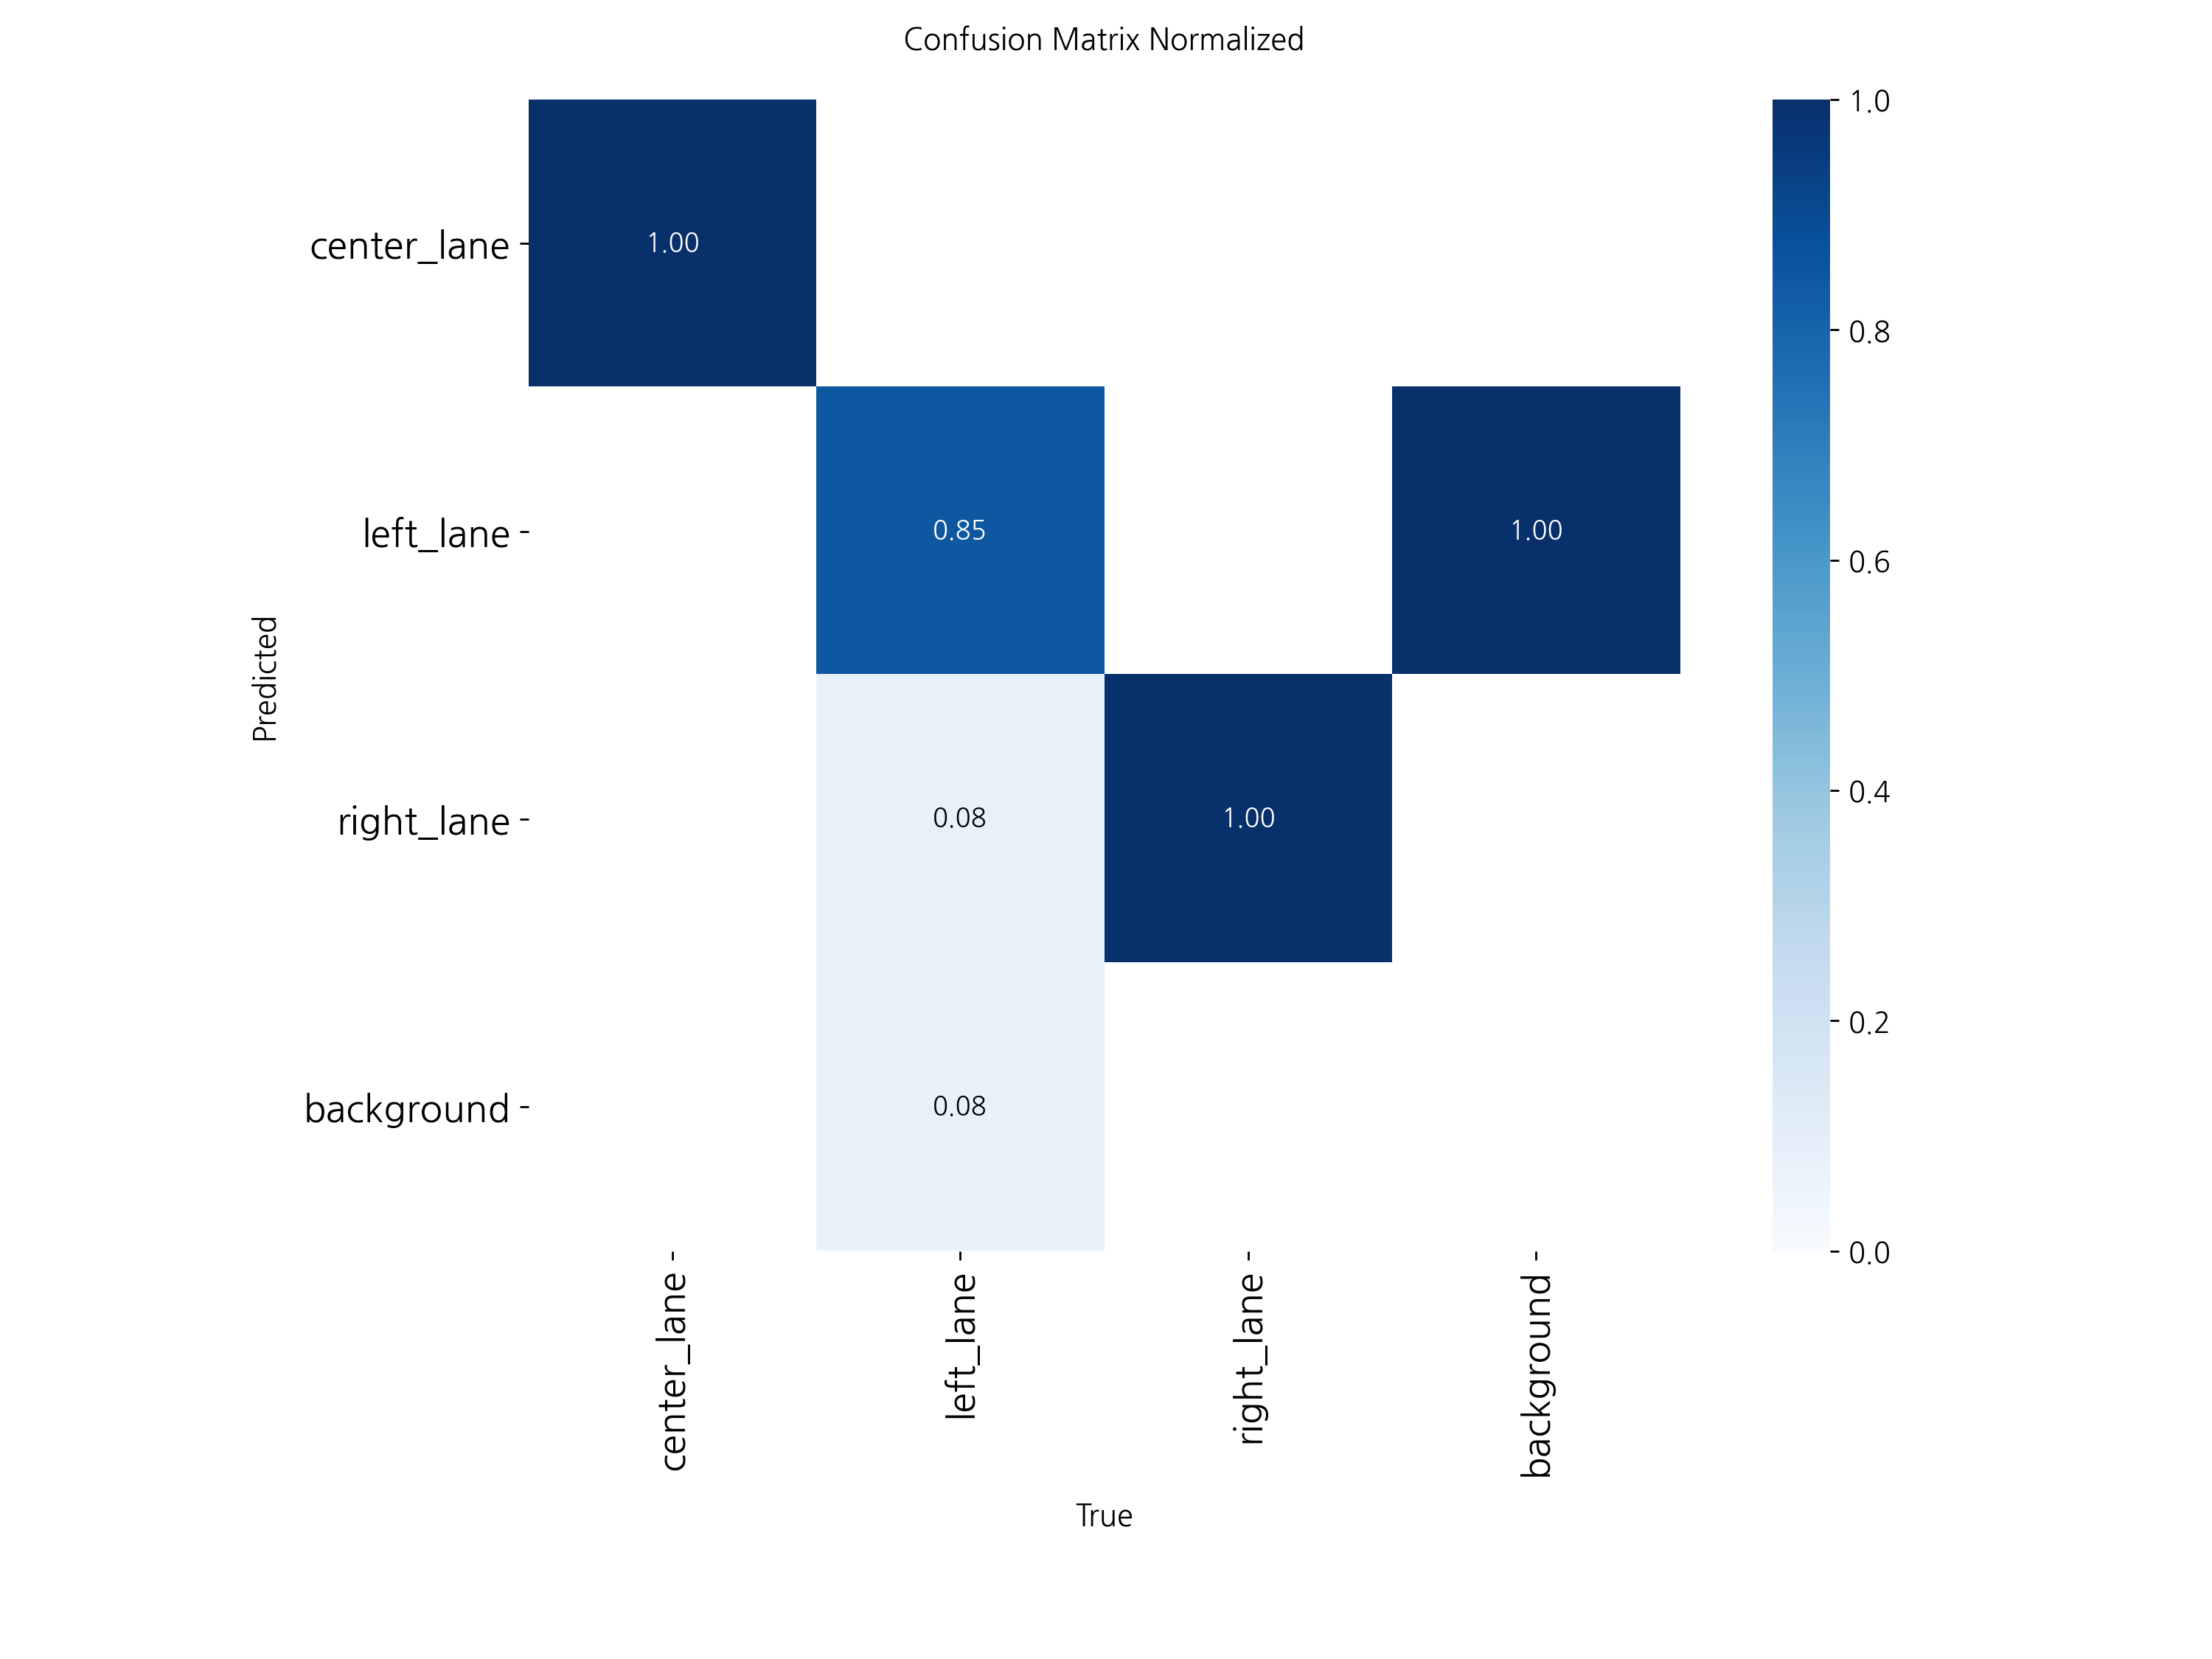

In [7]:
# Confusion Matrix 확인
confusion_matrix_png_path = f"runs/segment/06/confusion_matrix_normalized.png"
display(Image(confusion_matrix_png_path))

모델 평가

In [8]:
# 최적 가중치(best.pt) 로드
best_model = YOLO(f"runs/segment/06/weights/best.pt")

# 평가하기
test_results = best_model.val(
    data=f"{DATASET_PATH}/data.yaml",
    split="test",
    project="06",
    name="test",
    exist_ok=True,
    verbose=False,
)

print(f"\n[박스]")
print(f"mAP50    : {test_results.box.map50:.4f}")
print(f"mAP50-95 : {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall   : {test_results.box.mr:.4f}")

print(f"\n[마스크]")
print(f"mAP50    : {test_results.seg.map50:.4f}")
print(f"mAP50-95 : {test_results.seg.map:.4f}")
print(f"Precision: {test_results.seg.mp:.4f}")
print(f"Recall   : {test_results.seg.mr:.4f}")

val: Scanning /datasets/lane-seg/labels/test... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 13.8it/s 0.1s

[박스]
mAP50    : 0.9417
mAP50-95 : 0.7873
Precision: 0.9847
Recall   : 0.9444

[마스크]
mAP50    : 0.9417
mAP50-95 : 0.5674
Precision: 0.9847
Recall   : 0.9444
